In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')  # Add parent directory to path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax

# MarkovSBI imports
from markovsbi.tasks import get_task, VehicleDynamicsTask
from markovsbi.utils.sde_utils import init_sde
from markovsbi.models.simple_scoremlp import build_score_mlp, precondition_functions
from markovsbi.models.train_utils import build_batch_sampler, build_loss_fn
from markovsbi.sampling.score_fn import FNPEScoreFn, UncorrectedScoreFn
from markovsbi.sampling.sample import Diffuser
from markovsbi.sampling.kernels import EulerMaruyama

# Your existing imports
from configs.config import ExperimentConfig

print(f"JAX devices: {jax.devices()}")

c:\Users\aritr\anaconda3\envs\sbi_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CpuDevice(id=0)]


## 1. Setup Task and Configuration

In [3]:
# Configuration
key = jax.random.PRNGKey(42)

# Create vehicle dynamics task
# Use shorter trajectories for faster training (T_seg)
task = get_task(
    "vehicle_dynamics",
    active_parameters=("mu", "cd", "m"),  # All 3 parameters
    T_seg=100,  # Short trajectories for demo (use 1000+ for real training)
    dt=0.01,
)

prior = task.get_prior()
simulator = task.get_simulator()

print(f"Input shape (theta): {task.input_shape}")
print(f"Condition shape (x_t): {task.condition_shape}")

Input shape (theta): (3,)
Condition shape (x_t): (9,)


## 2. Generate Training Data

In [4]:
# Generate training data
# For real training, use num_simulations >= 100,000
NUM_SIMS = 1000  # Reduced for demo
T_OBS = 50  # Number of observation time steps

key, key_data = jax.random.split(key)
data = task.get_data(key_data, NUM_SIMS, T_OBS)

print(f"Thetas shape: {data['thetas'].shape}")
print(f"Xs shape: {data['xs'].shape}")

Generating data: 100%|██████████| 4/4 [00:01<00:00,  2.54batch/s]


Thetas shape: (1000, 3)
Xs shape: (1000, 50, 9)


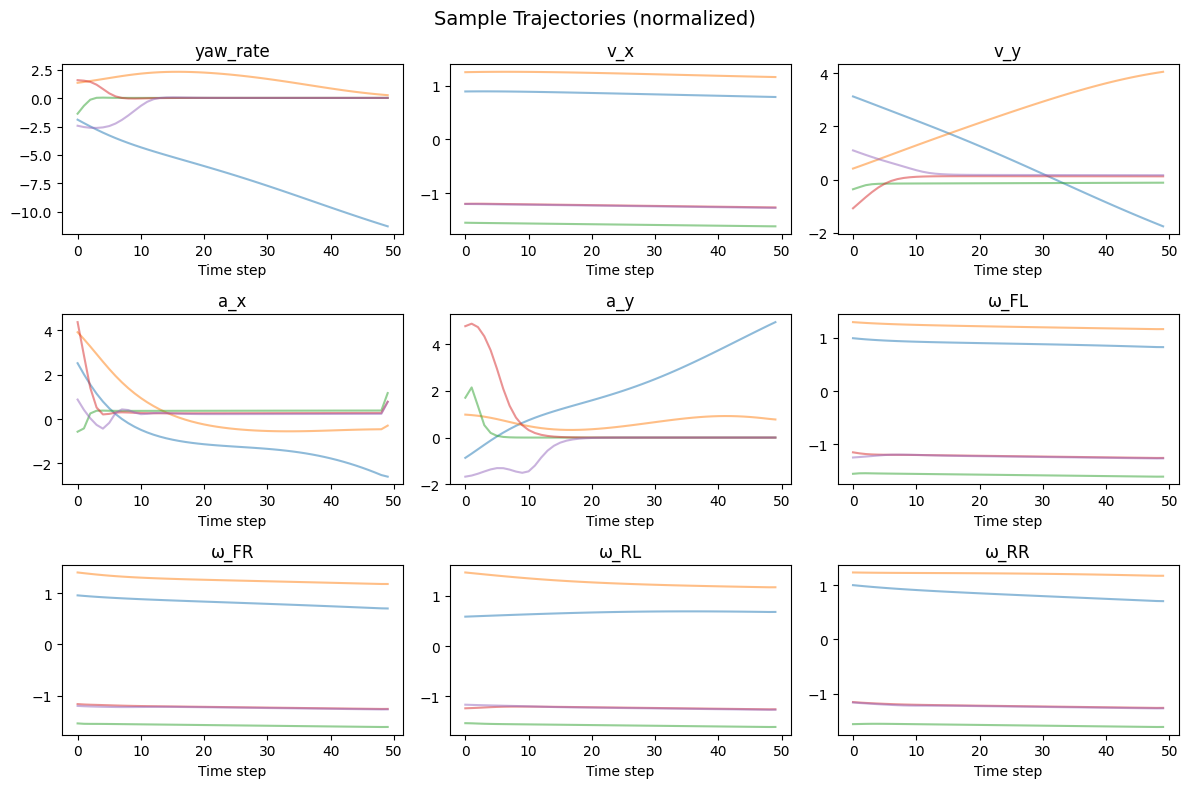

In [5]:
# Visualize some trajectories
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
obs_labels = ["yaw_rate", "v_x", "v_y", "a_x", "a_y", "ω_FL", "ω_FR", "ω_RL", "ω_RR"]

for i, ax in enumerate(axes.flat):
    if i < 9:
        for j in range(min(5, NUM_SIMS)):
            ax.plot(data['xs'][j, :, i], alpha=0.5)
        ax.set_title(obs_labels[i])
        ax.set_xlabel('Time step')

plt.suptitle('Sample Trajectories (normalized)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Initialize SDE and Score Network

In [6]:
# Initialize the variance-preserving SDE for diffusion
sde, weight_fn = init_sde(data)

print(f"SDE T_min: {sde.T_min}, T_max: {sde.T_max}")
print(f"Data mean (mu0): {sde.mu0}")
print(f"Data std (std0): {sde.std0}")

SDE T_min: 0.01, T_max: 1.0
Data mean (mu0): [-6.6947939e-07 -5.8174138e-08 -1.3642311e-06]
Data std (std0): [1.        0.9999999 0.9999999]


In [7]:
# Build score network
key, key_init = jax.random.split(key)

d = data['thetas'].shape[1]  # Parameter dimension (3 for mu, cd, m)

# Preconditioning functions for stable training
c_in, c_noise, c_out = precondition_functions(sde)

# Build MLP-based score network
# window_size controls how many time steps the network sees at once
init_fn, score_net = build_score_mlp(
    window_size=T_OBS,  # Full trajectory
    num_hidden=5,       # Number of hidden layers
    hidden_dim=128,     # Hidden dimension (increase for better capacity)
    c_in=c_in,
    c_noise=c_noise,
    c_out=c_out,
)

# Build batch sampler and loss function
batch_sampler = build_batch_sampler(data)
loss_fn = build_loss_fn(
    "dsm",  # Denoising Score Matching
    score_net,
    sde,
    weight_fn,
    control_variate=True,  # Variance reduction
)

In [8]:
# Initialize parameters
theta_batch, x_batch = batch_sampler(key_init, 32)
print(f"Batch shapes: theta={theta_batch.shape}, x={x_batch.shape}")

params = init_fn(key_init, jnp.ones((32,)), theta_batch, x_batch)
print(f"Model initialized with {sum(p.size for p in jax.tree_util.tree_leaves(params)):,} parameters")

Batch shapes: theta=(32, 3), x=(32, 50, 9)
Model initialized with 98,764 parameters


In [9]:
# Test loss function
initial_loss = loss_fn(params, key, theta_batch, x_batch)
print(f"Initial loss: {initial_loss:.4f}")

Initial loss: 3.2485


## 4. Training

In [10]:
# Setup optimizer with cosine schedule
NUM_EPOCHS = 10  # Increase for real training (20-50)
STEPS_PER_EPOCH = 1000  # Increase for real training (10000)
BATCH_SIZE = 256
LEARNING_RATE = 5e-4

total_steps = NUM_EPOCHS * STEPS_PER_EPOCH

schedule = optax.cosine_onecycle_schedule(
    total_steps,
    LEARNING_RATE,
)

optimizer = optax.chain(
    optax.adaptive_grad_clip(10.0),
    optax.adamw(schedule),
)

opt_state = optimizer.init(params)

In [11]:
# JIT-compiled update step
@jax.jit
def update(params, rng, opt_state, theta_batch, x_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng, theta_batch, x_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [12]:
# Training loop
losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for step in range(STEPS_PER_EPOCH):
        key, key_batch, key_loss = jax.random.split(key, 3)
        theta_batch, x_batch = batch_sampler(key_batch, BATCH_SIZE)
        loss, params, opt_state = update(params, key_loss, opt_state, theta_batch, x_batch)
        epoch_loss += loss / STEPS_PER_EPOCH
    
    losses.append(float(epoch_loss))
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Loss = {epoch_loss:.4f}")

Epoch 1/10: Loss = 19.5166
Epoch 2/10: Loss = 18.6856
Epoch 3/10: Loss = 17.6543
Epoch 4/10: Loss = 16.8446
Epoch 5/10: Loss = 16.5531
Epoch 6/10: Loss = 15.5521
Epoch 7/10: Loss = 15.0589
Epoch 8/10: Loss = 14.5299
Epoch 9/10: Loss = 13.2236
Epoch 10/10: Loss = 12.7174


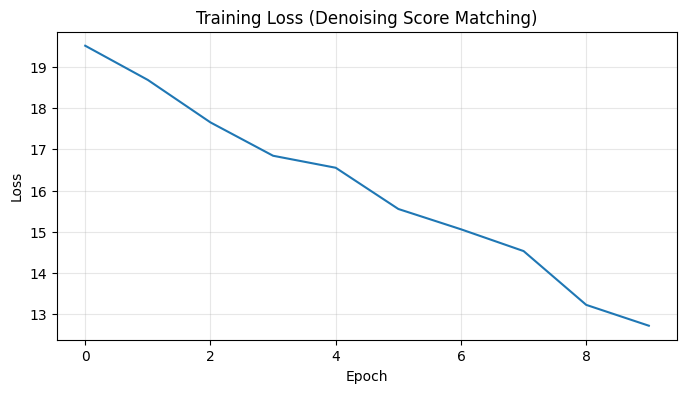

In [13]:
# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Denoising Score Matching)')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Setup Sampling (Reverse Diffusion)

In [14]:
# Choose score function type
# Options:
# - FNPEScoreFn: Original FNPE formulation
# - UncorrectedScoreFn: Uncorrected score (simpler)
# - CorrectedScoreFn: With correction term
# - GaussCorrectedScoreFn: Gaussian approximation correction

# Use normalized prior for sampling
prior_normalized = task.get_normalized_prior()

score_fn = FNPEScoreFn(score_net, params, sde, prior_normalized)
# Alternative:
# score_fn = UncorrectedScoreFn(score_net, params, sde, prior_normalized)

In [15]:
# Setup diffusion sampler
kernel = EulerMaruyama(score_fn)

# Time grid for reverse diffusion
num_diffusion_steps = 500
time_grid = jnp.linspace(sde.T_min, sde.T_max, num_diffusion_steps)

sampler = Diffuser(kernel, time_grid, (d,))

## 6. Test Inference on Simulated Data

In [16]:
# Generate a test observation
key, key_test = jax.random.split(key)

# Sample true theta from prior (in original space)
theta_true_phys = task.get_prior().sample(key_test)
print(f"True theta (physical): {theta_true_phys}")

# Simulate observation
key, key_sim = jax.random.split(key)
x_o_raw = simulator(key_sim, theta_true_phys, T_OBS)

# Normalize observation for inference
x_o = task.normalize_x(x_o_raw)
theta_true_norm = task.normalize_theta(theta_true_phys)

print(f"True theta (normalized): {theta_true_norm}")
print(f"Observation shape: {x_o.shape}")

True theta (physical): [6.2508976e-01 1.1028744e-01 1.8222981e+03]
True theta (normalized): [-1.3244009  -1.3884209   0.37341726]
Observation shape: (50, 9)


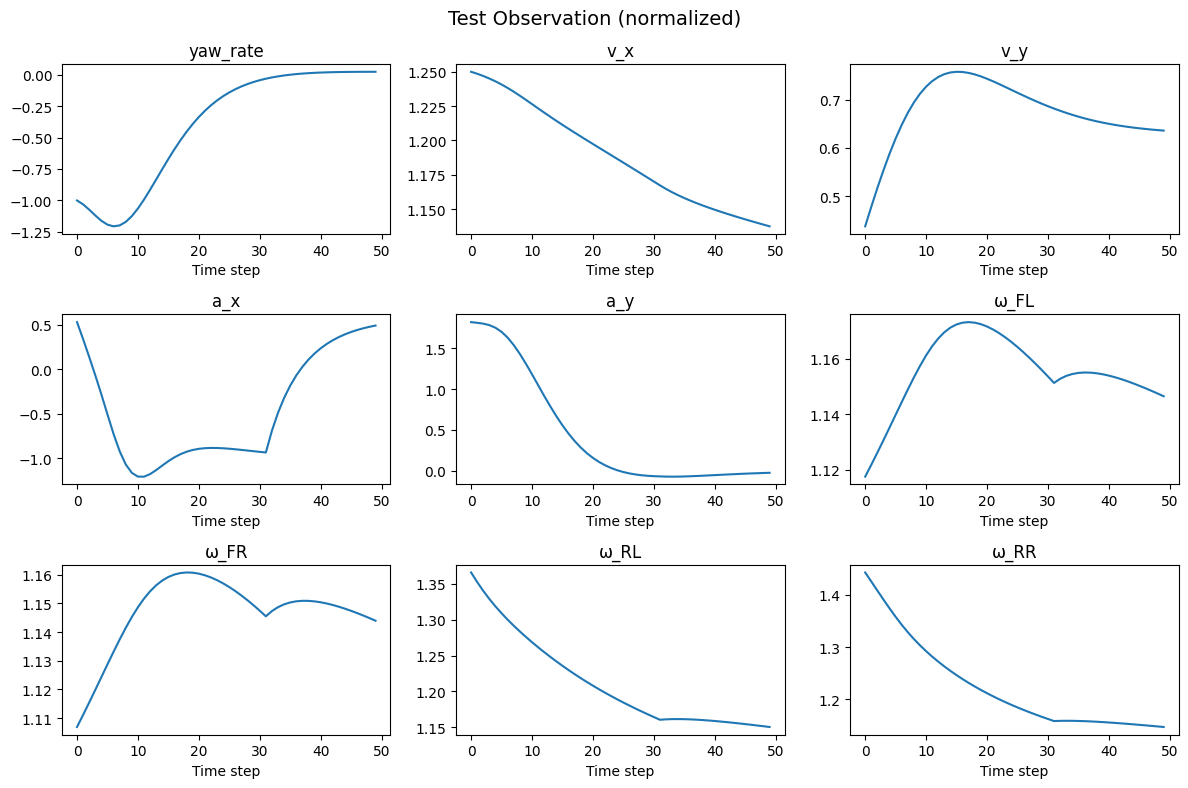

In [17]:
# Plot test observation
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < 9:
        ax.plot(x_o[:, i])
        ax.set_title(obs_labels[i])
        ax.set_xlabel('Time step')

plt.suptitle('Test Observation (normalized)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Sample from posterior via reverse diffusion
NUM_SAMPLES = 500

key, key_sample = jax.random.split(key)
samples_norm = jax.vmap(sampler.sample, in_axes=(0, None))(
    jax.random.split(key_sample, NUM_SAMPLES),
    x_o
)

# Unnormalize samples to physical space
samples_phys = jax.vmap(task.unnormalize_theta)(samples_norm)

print(f"Samples shape: {samples_phys.shape}")

Samples shape: (500, 3)


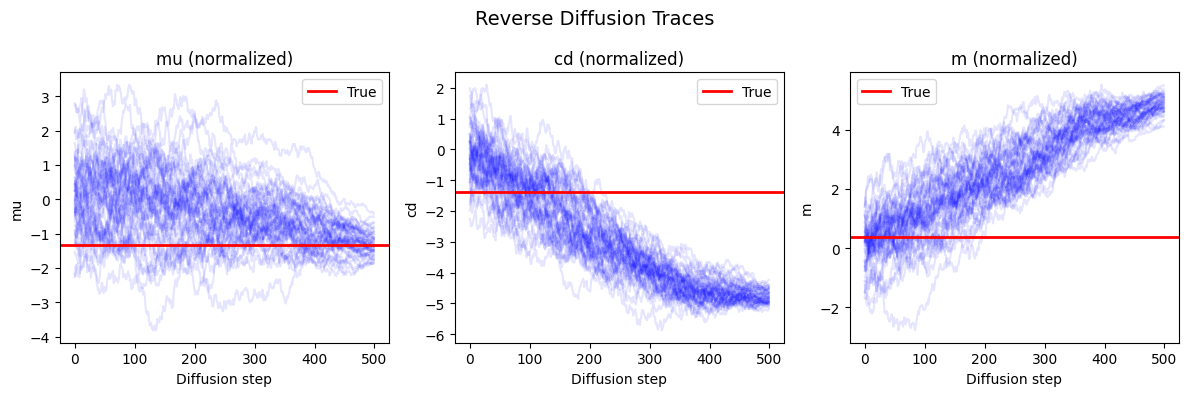

In [19]:
# Visualize diffusion traces (optional)
key, key_trace = jax.random.split(key)
traces = jax.vmap(sampler.simulate, in_axes=(0, None))(
    jax.random.split(key_trace, 50),
    x_o
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
param_names = list(task.cfg.active_parameters)

for i, ax in enumerate(axes):
    for trace in traces:
        ax.plot(trace[:, i], alpha=0.1, color='blue')
    ax.axhline(theta_true_norm[i], color='red', lw=2, label='True')
    ax.set_xlabel('Diffusion step')
    ax.set_ylabel(param_names[i])
    ax.set_title(f'{param_names[i]} (normalized)')
    ax.legend()

plt.suptitle('Reverse Diffusion Traces', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Posterior Analysis

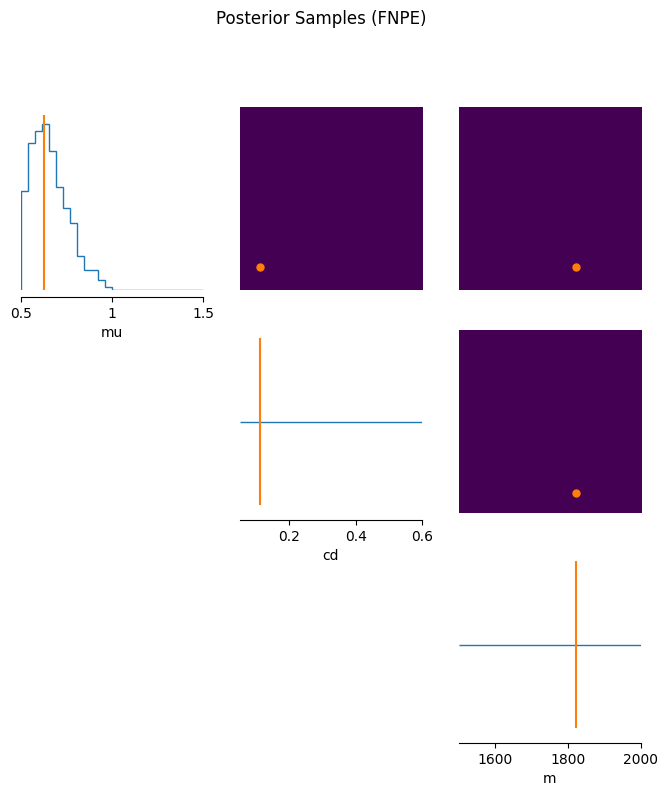

In [20]:
# Convert to numpy for plotting
samples_np = np.array(samples_phys)
theta_true_np = np.array(theta_true_phys)

# Pairplot (if sbi is available)
try:
    from sbi.analysis import pairplot
    
    # Define limits based on prior
    bounds = task.cfg.param_bounds()
    limits = [
        (bounds[p][0], bounds[p][1])
        for p in task.cfg.active_parameters
    ]
    
    pairplot(
        [samples_np],
        points=theta_true_np,
        limits=limits,
        labels=list(task.cfg.active_parameters),
        figsize=(8, 8),
    )
    plt.suptitle('Posterior Samples (FNPE)', y=1.02)
    plt.show()
    
except ImportError:
    # Manual histogram if sbi not available
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    for i, (ax, name) in enumerate(zip(axes, task.cfg.active_parameters)):
        ax.hist(samples_np[:, i], bins=50, density=True, alpha=0.7)
        ax.axvline(theta_true_np[i], color='red', lw=2, label='True')
        ax.set_xlabel(name)
        ax.set_ylabel('Density')
        ax.legend()
    
    plt.suptitle('Posterior Marginals (FNPE)', fontsize=14)
    plt.tight_layout()
    plt.show()

In [21]:
# Summary statistics
print("\n=== Posterior Summary ===")
print(f"{'Parameter':<10} {'True':>10} {'Mean':>10} {'Std':>10} {'Error':>10}")
print("-" * 52)

for i, name in enumerate(task.cfg.active_parameters):
    true_val = float(theta_true_np[i])
    mean_val = float(samples_np[:, i].mean())
    std_val = float(samples_np[:, i].std())
    error = abs(mean_val - true_val)
    print(f"{name:<10} {true_val:>10.4f} {mean_val:>10.4f} {std_val:>10.4f} {error:>10.4f}")


=== Posterior Summary ===
Parameter        True       Mean        Std      Error
----------------------------------------------------
mu             0.6251     0.6290     0.1168     0.0039
cd             0.1103    -0.4291     0.0347     0.5394
m           1822.2981  2465.2429    35.9576   642.9448


## 8. Save Model and Normalization Stats

In [ ]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# Create experiment directory
exp_name = f"fnpe_vehicle_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
exp_dir = Path(f"../experiments/{exp_name}")
exp_dir.mkdir(parents=True, exist_ok=True)

# Save model parameters
with open(exp_dir / "params.pkl", "wb") as f:
    pickle.dump(params, f)

# Save normalization stats
norm_stats = task.get_normalization_stats()
norm_stats_serializable = {
    k: v.tolist() if hasattr(v, 'tolist') else v
    for k, v in norm_stats.items()
}
with open(exp_dir / "normalization_stats.json", "w") as f:
    json.dump(norm_stats_serializable, f, indent=2)

# Save config
config = {
    "active_parameters": list(task.cfg.active_parameters),
    "T_seg": task.cfg.T_seg,
    "dt": task.cfg.dt,
    "num_simulations": NUM_SIMS,
    "T_obs": T_OBS,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
}
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved experiment to {exp_dir}")

## 9. Inference on Real Data (Example)

To use with real data, you need to:
1. Load the CSV and extract observations
2. Normalize using the fitted statistics
3. Sample from the posterior

In [ ]:
# Example: Inference on real data
# (Uncomment and modify paths as needed)

# import pandas as pd
# from utils.real_data import prep_x_obs_from_df
#
# # Load real CSV
# df_real = pd.read_csv("path/to/real_data.csv")
#
# # Extract observations (first T_OBS time steps)
# x_real = prep_x_obs_from_df(
#     df_real,
#     start_idx=0,
#     T=T_OBS,
#     rate_body_z_in_deg_s=True,
# )
#
# # Normalize
# x_real_norm = task.normalize_x(jnp.array(x_real.numpy()))
#
# # Sample from posterior
# samples_real_norm = jax.vmap(sampler.sample, in_axes=(0, None))(
#     jax.random.split(jax.random.PRNGKey(0), 1000),
#     x_real_norm
# )
# samples_real_phys = jax.vmap(task.unnormalize_theta)(samples_real_norm)
#
# print(f"Inferred parameters:")
# for i, name in enumerate(task.cfg.active_parameters):
#     print(f"  {name}: {samples_real_phys[:, i].mean():.4f} ± {samples_real_phys[:, i].std():.4f}")

## Summary

This notebook demonstrated:

1. **Task Setup**: Created `VehicleDynamicsTask` that wraps your JAX simulator
2. **Data Generation**: Generated training data in MarkovSBI format
3. **Score Network**: Built and trained an MLP score network using DSM
4. **Sampling**: Used FNPE score function with Euler-Maruyama reverse diffusion
5. **Inference**: Sampled posterior parameters for test observations

### Key Hyperparameters to Tune:
- `NUM_SIMS`: More data → better posterior (100k+ recommended)
- `T_OBS`: Longer observations → more information
- `hidden_dim`, `num_hidden`: Network capacity
- `num_diffusion_steps`: More steps → better samples but slower
- Score function type: Try `FNPEScoreFn` vs `UncorrectedScoreFn`